# Structural Estimation

This notebook implements the dynamic discrete choice model from `slides.tex`.

In [1]:
# Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.stats import norm
import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed
import time

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax.scipy.special import logsumexp as jax_logsumexp

### Load Data

In [2]:
df = pd.read_csv("./kkbox-subsample/panel_user_month.csv")

# user_ids = pd.Series(df["msno"].unique()).iloc[:300].tolist()
# df = df[df["msno"].isin(user_ids)].copy()

# Map observed statuses to model actions
status_to_action = {
    "churn": 0,
    "active": 1,
    "paused": 2,
}
df["action"] = df["subscription_status"].map(status_to_action)

df = df.sort_values(["msno", "user_tenure"]).reset_index(drop=True)

# Previous action for inertia term; initialize first month as previous active
df["prev_action"] = df.groupby("msno")["action"].shift(1)
df["prev_action"] = df["prev_action"].fillna(1).astype(int)

df["R_i"] = df.groupby("msno")["auto_renewal"].transform("first").astype(float)
df["p_i"] = df.groupby("msno")["price"].transform("first").astype(float)

df.head()

,msno,user_tenure,subscription_status,monthly_hours,cum_hours,auto_renewal,transaction_date,membership_expire_date,price,action,prev_action,R_i,p_i
0,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,0,active,39.826280,0.000000,0.0,20150215.0,20150317.0,149.0,1,1,0.0,149.0
1,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,1,active,16.865030,39.826280,0.0,20150320.0,20150419.0,149.0,1,1,0.0,149.0
2,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,2,active,20.236815,56.691311,0.0,20150421.0,20150521.0,149.0,1,1,0.0,149.0
3,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,3,active,17.657869,76.928126,0.0,20150522.0,20150621.0,149.0,1,1,0.0,149.0
4,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,4,active,11.805867,94.585995,0.0,20150621.0,20150721.0,149.0,1,1,0.0,149.0


In [3]:
# Discretize accumulated hours into bins

hour_edges = np.array([0.0, 25.0, 100.0, 250.0, 500.0, np.inf])
H = len(hour_edges) - 1

df["h_bin"] = pd.cut(
    df["cum_hours"],
    bins=hour_edges,
    include_lowest=True,
    labels=False,
).astype(int)

df[["msno", "cum_hours", "h_bin"]].head(10)

,msno,cum_hours,h_bin
0,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,0.000000,0
1,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,39.826280,1
2,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,56.691311,1
3,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,76.928126,1
4,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,94.585995,1
5,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,106.391862,2
6,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,108.420437,2
7,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,108.420437,2
8,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,121.918446,2
9,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,122.889533,2


### Cumulative listening over tenure

Each line traces one user's accumulated listening hours (`cum_hours`) against months since first observation (`user_tenure`). The right panel summarizes the cross-sectional distribution at each tenure month (median and 25th–75th percentiles). Horizontal dashed lines mark the hour-bin edges used in the state space.

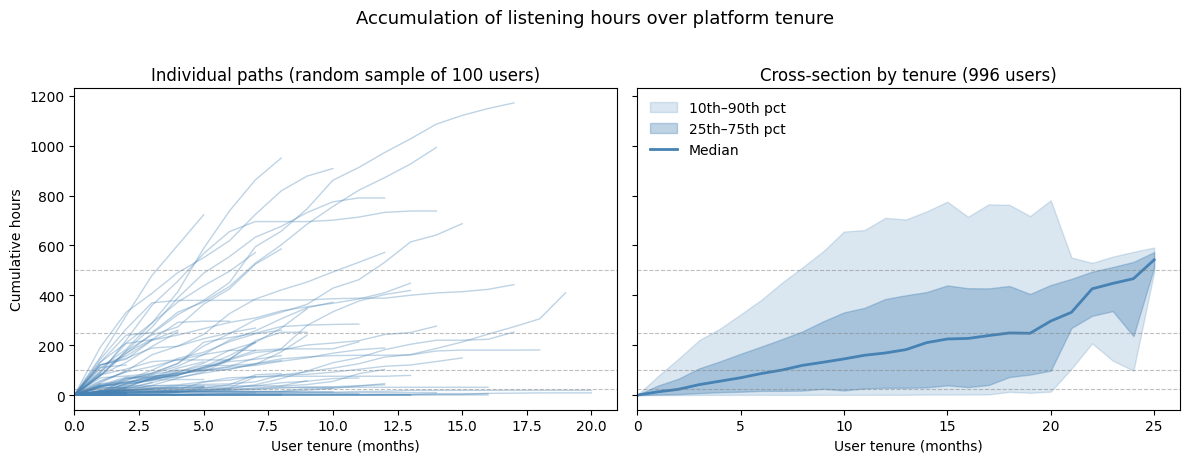

Users: 996 | Observations: 8,959 | Max tenure: 25 months


In [4]:
plot_df = df.sort_values(["msno", "user_tenure"]).copy()
n_users = plot_df["msno"].nunique()

# Cross-sectional summary by tenure month
tenure_summary = (
    plot_df.groupby("user_tenure", as_index=False)["cum_hours"]
    .agg(
        median="median",
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        p10=lambda s: s.quantile(0.10),
        p90=lambda s: s.quantile(0.90),
        n_users="count",
    )
)

# Spaghetti sample: fixed seed for reproducibility
rng = np.random.default_rng(0)
sample_users = rng.choice(plot_df["msno"].unique(), size=min(100, n_users), replace=False)
spaghetti = plot_df[plot_df["msno"].isin(sample_users)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# --- Left: individual trajectories ---
ax0 = axes[0]
for msno, g in spaghetti.groupby("msno"):
    ax0.plot(
        g["user_tenure"],
        g["cum_hours"],
        color="steelblue",
        alpha=0.35,
        linewidth=1.0,
    )
for y in hour_edges[1:-1]:
    ax0.axhline(y, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax0.set_xlabel("User tenure (months)")
ax0.set_ylabel("Cumulative hours")
ax0.set_title(f"Individual paths (random sample of {len(sample_users)} users)")
ax0.set_xlim(left=0)

# --- Right: cross-sectional bands ---
ax1 = axes[1]
t = tenure_summary["user_tenure"]
ax1.fill_between(t, tenure_summary["p10"], tenure_summary["p90"], color="steelblue", alpha=0.2, label="10th–90th pct")
ax1.fill_between(t, tenure_summary["p25"], tenure_summary["p75"], color="steelblue", alpha=0.35, label="25th–75th pct")
ax1.plot(t, tenure_summary["median"], color="steelblue", linewidth=2.0, label="Median")
for y in hour_edges[1:-1]:
    ax1.axhline(y, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax1.set_xlabel("User tenure (months)")
ax1.set_title(f"Cross-section by tenure ({n_users} users)")
ax1.legend(loc="upper left", frameon=False)
ax1.set_xlim(left=0)

fig.suptitle("Accumulation of listening hours over platform tenure", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

print(f"Users: {n_users} | Observations: {len(plot_df):,} | Max tenure: {plot_df['user_tenure'].max()} months")

In [5]:
# Build empirical active-user transition matrix for h_bin
# T[h, h'] = P(h_{t+1}=h' | h_t=h, a_t=1)

active_rows = df.copy()
active_rows["h_bin_next"] = active_rows.groupby("msno")["h_bin"].shift(-1)
active_rows = active_rows[(active_rows["action"] == 1) & (active_rows["h_bin_next"].notna())].copy()
active_rows["h_bin_next"] = active_rows["h_bin_next"].astype(int)
counts = np.zeros((H, H), dtype=float)
for _, r in active_rows.iterrows():
    counts[int(r["h_bin"]), int(r["h_bin_next"])] += 1.0
T = np.zeros((H, H), dtype=float)
for h in range(H):
    row_sum = counts[h].sum()
    if row_sum > 0:
        T[h] = counts[h] / row_sum
    else:
        T[h, h] = 1.0

pd.DataFrame(T)

,0,1,2,3,4
0,0.819378,0.162978,0.015251,0.002093,0.000299
1,0.000000,0.795548,0.203281,0.001172,0.000000
2,0.000000,0.000000,0.834875,0.165125,0.000000
3,0.000000,0.000000,0.000000,0.874434,0.125566
4,0.000000,0.000000,0.000000,0.000000,1.000000


In [6]:
# Enumerate the dynamic state space
# Omega_t = (h_t, a_{t-1})

a_prev_vals = np.array([0, 1, 2], dtype=int)

state_tuples = []
for h in range(H):
    for a_prev in a_prev_vals:
        state_tuples.append((int(h), int(a_prev)))

state_to_idx = {s: i for i, s in enumerate(state_tuples)}
idx_to_state = {i: s for s, i in state_to_idx.items()}

n_states = len(state_tuples)
n_actions = 3  # churn, active, pause

In [7]:
# Transition matrices P[a, s, s_next]
# Build action-specific transition tensor under model assumptions:
#   - a=0 churn: absorbing terminal action with zero continuation value,
#                implemented as self-transition (continuation still zero since v0=0 forever)
#   - a=1 active: h transitions via empirical T, next a_prev = 1
#   - a=2 pause: h is frozen, next a_prev = 2

P = np.zeros((3, n_states, n_states), dtype=float)

for s_idx, (h_bin, a_prev) in enumerate(state_tuples):
    # a = 0 (churn): absorbing
    P[0, s_idx, s_idx] = 1.0

    # a = 1 (active): draw h' from empirical active transition, set a_prev' = 1
    for h_next in range(H):
        s_next = (int(h_next), 1)
        s_next_idx = state_to_idx[s_next]
        P[1, s_idx, s_next_idx] += T[h_bin, h_next]

    # a = 2 (pause): keep h fixed, set a_prev' = 2
    s_next_pause = (int(h_bin), 2)
    s_next_pause_idx = state_to_idx[s_next_pause]
    P[2, s_idx, s_next_pause_idx] = 1.0

print("Transition tensor shape:", P.shape)

Transition tensor shape: (3, 15, 15)


In [8]:
# map observed panel rows to state indices used by DP

def attach_state_index(df_panel, state_to_idx):
    df_out = df_panel.copy()
    df_out["state_tuple"] = list(
        zip(
            df_out["h_bin"].astype(int),
            df_out["prev_action"].astype(int),
        )
    )
    df_out["state_idx"] = df_out["state_tuple"].map(state_to_idx)

    missing = df_out["state_idx"].isna().sum()
    if missing > 0:
        raise ValueError(f"Found {missing} rows with state not in state space.")

    df_out["state_idx"] = df_out["state_idx"].astype(int)
    return df_out


df_model = attach_state_index(df, state_to_idx)
df_model[["msno", "user_tenure", "action", "prev_action", "h_bin", "state_idx", "R_i", "p_i"]].head(10)

,msno,user_tenure,action,prev_action,h_bin,state_idx,R_i,p_i
0,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,0,1,1,0,1,0.0,149.0
1,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,1,1,1,1,4,0.0,149.0
2,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,2,1,1,1,4,0.0,149.0
3,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,3,1,1,1,4,0.0,149.0
4,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,4,1,1,1,4,0.0,149.0
5,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,5,1,1,2,7,0.0,149.0
6,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,6,2,1,2,7,0.0,149.0
7,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,7,1,2,2,8,0.0,149.0
8,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,8,1,1,2,7,0.0,149.0
9,++nqzXpLn1fFKdCWEO5X5ufg5RJV9FgPMsKuHrnwk1I=,9,0,1,2,7,0.0,149.0


In [9]:
# Vectorized index arrays used inside the objective

# One integer index per (R_i, p_i) type
unique_types = (
    df_model[["R_i", "p_i"]]
    .drop_duplicates()
    .sort_values(["R_i", "p_i"])
    .reset_index(drop=True)
)
type_pairs = list(zip(
    unique_types["R_i"].to_numpy(dtype=float),
    unique_types["p_i"].to_numpy(dtype=float),
))
type_to_idx = {pair: i for i, pair in enumerate(type_pairs)}

# One integer index per household (msno) for clustering and per-individual scores
_, hh_index_np = np.unique(df_model["msno"].to_numpy(), return_inverse=True)
hh_index_np = hh_index_np.astype(int)

# Observation-level arrays
s_idx_np = df_model["state_idx"].to_numpy(dtype=int)
a_obs_np = df_model["action"].to_numpy(dtype=int)
type_idx_np = np.array([
    type_to_idx[(float(R_i), float(p_i))]
    for R_i, p_i in zip(df_model["R_i"].to_numpy(), df_model["p_i"].to_numpy())
], dtype=int)

# State-level arrays for vectorized utility construction
h_of_state_np = np.array([s[0] for s in state_tuples], dtype=int)
a_prev_of_state_np = np.array([s[1] for s in state_tuples], dtype=int)

# Type-level arrays
R_type_np = unique_types["R_i"].to_numpy(dtype=float)
p_type_np = unique_types["p_i"].to_numpy(dtype=float)

print(
    f"n_individuals: {hh_index_np.max() + 1} | "
    f"n_types: {len(unique_types)} | "
    f"n_states: {len(state_tuples)} | "
    f"n_obs: {len(df_model)}"
)

n_individuals: 996 | n_types: 9 | n_states: 15 | n_obs: 8959


### Flow utility specification

<div style="display:none">
$\newcommand{\bm}[1]{\mathbf{#1}}$
</div>

Each household $i$ has a time-invariant type $(R_i, p_i)$ (auto-renewal flag and price) and a time-varying state $\omega_t = (h_t, a_{t-1})$ collecting their accumulated-hours bin $h_t$ and the previous month's action $a_{t-1}$. In month $t$ they choose $a_t \in \{0, 1, 2\}$ representing churn, active, and paused subscriptions respectively, drawing iid Type-I EV shocks $\varepsilon_{ait}$. The deterministic component of flow utility is

$$
\begin{aligned}
v_0(\omega_t; \bm\theta) &= 0 \\
v_1(\omega_t; R_i, p_i, \bm\theta) &= \bar{u}_1 + \alpha R_i - \beta p_i + \eta \mathbf{1}\{a_{t-1} = 1\} + \gamma_{h_t} \\
v_2(\omega_t; \bm\theta) &= \bar{u}_2 + \eta \mathbf{1}\{a_{t-1} = 2\}
\end{aligned}
$$

Churn is normalized to zero. Because $\bar{u}_1$ enters as a level only $\gamma_h - \gamma_1$ is separately identified from $\bar{u}_1$, so we normalize the lowest-bin slope to $\gamma_1 \equiv 0$ (absorbed into $\bar{u}_1$) and estimate the deviations $\gamma_2, \ldots, \gamma_H$. The free-parameter vector is $\bm\theta = (\bar{u}_1, \bar{u}_2, \alpha, \beta, \eta, \gamma_2, \ldots, \gamma_H)$, with $4 + H$ entries.

### Nested fixed-point likelihood

<div style="display:none">
$\newcommand{\bm}[1]{\mathbf{#1}}$
</div>

Conditional on $\bm\theta$, the action-specific value function $\nu_a(\omega; \bm\theta)$ solves the Bellman equation
$$
\nu_a(\omega; \bm\theta)
= u_a(\omega; \bm\theta) + \delta \sum_{\omega'} P(\omega' \mid \omega, a) \, \mathrm{logsumexp}_{a'} \nu_{a'}(\omega'; \bm\theta).
$$
Under Type-I EV shocks the conditional choice probabilities (CCPs) are
$$
\Pr(a_t = a \mid \omega_t; \bm\theta) = \frac{\exp \nu_a(\omega_t; \bm\theta)}{\sum_{a'} \exp \nu_{a'}(\omega_t; \bm\theta)}.
$$

We estimate $\bm\theta$ by nested fixed-point MLE. For each candidate $\bm\theta$, the inner loop computes $\nu(\cdot; \bm\theta)$ by value iteration on the batched Bellman operator (vectorized across types so each $(R_i, p_i)$ shares the same $P$ but has a type-specific $u_a$). The outer loop maximizes
$$
\ell(\bm\theta) = \sum_{i=1}^N \sum_{t=1}^{T_i} \log \Pr(a_{it} \mid \omega_{it}; \bm\theta)
$$
using `scipy.optimize.minimize` with the JAX-computed analytic gradient. Standard errors are obtained from the JAX-computed Hessian (or its sandwich form when `robust_se=True`, clustering on the individual identifier).

In [10]:
def _unpack_theta(theta_vec, H):
    """
    Unpack the flat parameter vector into a dict with the structural coefficients.
    Free-parameter ordering is [u1_bar, u2_bar, alpha, beta, eta, gamma_2, ..., gamma_H],
    a length-(4 + H) vector. The lowest-bin slope gamma_1 is normalized to 0 (absorbed
    into u1_bar), so the returned ``gamma`` is a length-H vector with ``gamma[0] = 0``.
    """
    gamma_free = theta_vec[5:5 + H - 1]
    gamma = jnp.concatenate([jnp.zeros((1,)), gamma_free])
    return {
        "u1_bar": theta_vec[0],
        "u2_bar": theta_vec[1],
        "alpha": theta_vec[2],
        "beta": theta_vec[3],
        "eta": theta_vec[4],
        "gamma": gamma,
    }


def _build_U_all_types(theta, R_type, p_type, h_of_state, a_prev_of_state):
    """
    Build the deterministic flow-utility tensor U with shape (n_types, n_actions=3, n_states),
    where U[t, a, s] is the flow utility of action a in state s for type t.

    Implements the spec from the slides:
        v0 = 0
        v1 = u1_bar + alpha * R - beta * p + eta * 1{a_prev = 1} + gamma_h
        v2 = u2_bar + eta * 1{a_prev = 2}
    """
    gamma_state = theta["gamma"][h_of_state]                            # (S,)
    inertia_active = (a_prev_of_state == 1).astype(jnp.float64)         # (S,)
    inertia_pause = (a_prev_of_state == 2).astype(jnp.float64)          # (S,)
    active_type_level = (theta["u1_bar"] + theta["alpha"] * R_type
                         + theta["beta"] * p_type)[:, None]             # (T, 1)

    n_types = R_type.shape[0]
    n_states = h_of_state.shape[0]

    U0 = jnp.zeros((n_types, n_states))
    U1 = active_type_level + theta["eta"] * inertia_active[None, :] + gamma_state[None, :]
    U2 = jnp.broadcast_to(theta["u2_bar"] + theta["eta"] * inertia_pause[None, :],
                          (n_types, n_states))
    return jnp.stack([U0, U1, U2], axis=1)                              # (T, 3, S)


def _bellman_solve(U_all, P, delta, max_iter):
    """
    Inner NFXP loop: solve the action-specific value function fixed point
        Nu_a(s) = U_a(s) + delta * sum_{s'} P(s' | s, a) * logsumexp_a' Nu_a'(s')
    by batched value iteration. Uses a fixed loop count via jax.lax.fori_loop so
    reverse-mode autodiff is well-defined (no dynamic while loops).

    U_all : (T, A, S), P : (A, S, S)  ->  Nu : (T, A, S)
    """
    Nu0 = jnp.zeros_like(U_all)

    def body(i, Nu):
        cont_vals = jax_logsumexp(Nu, axis=1)                          # (T, S)
        EV = jnp.einsum("ask,tk->tas", P, cont_vals)                   # (T, A, S)
        return U_all + delta * EV

    return jax.lax.fori_loop(0, max_iter, body, Nu0)


def _negloglik_obs(theta_vec, arrays, H, delta, bellman_iter):
    """Negative log-likelihood for each observation. Shape (n_obs,)."""
    theta = _unpack_theta(theta_vec, H)
    U_all = _build_U_all_types(
        theta,
        R_type=arrays["R_type"],
        p_type=arrays["p_type"],
        h_of_state=arrays["h_of_state"],
        a_prev_of_state=arrays["a_prev_of_state"],
    )
    Nu_all = _bellman_solve(U_all, arrays["P"], delta, bellman_iter)   # (T, A, S)

    # Gather Nu[type_obs, :, s_obs] -> shape (n_obs, A) of action-specific values at the observed state
    Nu_obs = Nu_all[arrays["type_idx"], :, arrays["s_idx"]]
    log_p = (Nu_obs[jnp.arange(Nu_obs.shape[0]), arrays["a_obs"]]
             - jax_logsumexp(Nu_obs, axis=1))
    return -log_p


def _negloglik_hh(theta_vec, arrays, H, delta, bellman_iter):
    """Negative log-likelihood summed within each household. Shape (n_individuals,)."""
    nll_obs = _negloglik_obs(theta_vec, arrays, H, delta, bellman_iter)
    return jax.ops.segment_sum(nll_obs, arrays["hh_index"], num_segments=arrays["n_individuals"])


def _negloglik(theta_vec, arrays, H, delta, bellman_iter):
    """Summed negative log-likelihood."""
    return jnp.sum(_negloglik_obs(theta_vec, arrays, H, delta, bellman_iter))


def _score_matrix(theta_vec, arrays, H, delta, bellman_iter):
    """
    Score matrix d(NLL_h)/d theta with shape (n_individuals, n_params).
    Used for clustered (sandwich) standard errors.
    """
    def f(th):
        return _negloglik_hh(th, arrays, H, delta, bellman_iter)
    return np.asarray(jax.jacrev(f)(theta_vec))


def _print_ddc_output(output, n_obs, n_individuals, coef_names, robust_se, individual_var):
    """Prints NFXP MLE results in a nice table."""
    theta_hat = np.asarray(output["opt_theta"], dtype=float).reshape(-1)
    se_theta = np.asarray(output["se_theta"], dtype=float).reshape(-1)
    ci_theta = np.asarray(output["ci_theta"], dtype=float)
    if ci_theta.ndim == 1:
        ci_theta = ci_theta.reshape(-1, 2)

    print(output.get("message", ""))
    print(f"Converged in {output['num_iter']} iterations.")
    print()
    print(f"Log-likelihood: {output['opt_ll']:.4f}")
    print(f"Number of individuals: {n_individuals}")
    print(f"Number of observations: {n_obs}")
    print(f"Number of parameters estimated: {theta_hat.shape[0]}")
    if robust_se:
        print(f"Robust standard errors, clustered on the {individual_var} variable.")
    else:
        print("Standard errors are not robust and assume correct model specification.")
    print()

    widths = (12, 12, 11, 10, 10)
    header_top = (f"{'Coefficient':^{widths[0]}} | {'Estimate':^{widths[1]}} | "
                  f"{'Std. Err.':^{widths[2]}} | "
                  f"{'[Confidence Interval]':^{widths[3] + widths[4] + 3}}")
    divider = "-+-".join("-" * w for w in widths)

    print("Structural Coefficients")
    print(header_top)
    print(divider)
    for i, name in enumerate(coef_names):
        print(" | ".join([
            f"{name:<{widths[0]}}",
            f"{theta_hat[i]:>{widths[1]}.6f}",
            f"{se_theta[i]:>{widths[2]}.6f}",
            f"{ci_theta[i, 0]:>{widths[3]}.5f}",
            f"{ci_theta[i, 1]:>{widths[4]}.5f}",
        ]))


def _ddc_estimator(arrays, H, delta, bellman_iter, theta_init,
                   ci_alpha, robust_se, opt_method):
    """
    Estimates the dynamic discrete choice model by nested fixed-point MLE,
    from a single initial value `theta_init`. Returns SE / CIs from the
    JAX Hessian (sandwich form if `robust_se=True`).
    """
    arrays_j = {k: (jnp.asarray(v) if isinstance(v, np.ndarray) else v)
                for k, v in arrays.items()}

    def _nll(th):
        return _negloglik(th, arrays_j, H, delta, bellman_iter)

    nll_jit = jax.jit(_nll)
    grad_jit = jax.jit(jax.grad(_nll))
    hess_jit = jax.jit(jax.hessian(_nll))

    def obj_np(th):
        return float(nll_jit(jnp.asarray(th, dtype=jnp.float64)))

    def grad_np(th):
        return np.asarray(grad_jit(jnp.asarray(th, dtype=jnp.float64)), dtype=float)

    result = minimize(
        fun=obj_np,
        jac=grad_np,
        x0=np.asarray(theta_init, dtype=float),
        method=opt_method,
    )

    opt_ll = -float(result.fun)
    opt_theta = result.x

    # SE via pinv of the Hessian 
    H_obs = np.asarray(hess_jit(jnp.asarray(opt_theta, dtype=jnp.float64)))
    H_inv = np.linalg.pinv(H_obs)
    se_theta = np.sqrt(np.clip(np.diag(H_inv), 0.0, None))

    z = norm.ppf(1 - ci_alpha / 2)
    ci_theta = [(coef - z * se, coef + z * se) for coef, se in zip(opt_theta, se_theta)]

    output = {
        "opt_ll": opt_ll,
        "opt_theta": opt_theta,
        "opt_theta_dict": _unpack_theta(opt_theta, H),
        "se_theta": se_theta,
        "ci_theta": ci_theta,
        "param_cov": H_inv,
        "success": result.success,
        "message": result.message,
        "num_iter": result.nit,
    }

    if robust_se:
        # J estimated by outer products of household-level scores; sandwich V = H^{-1} J H^{-1}
        S = _score_matrix(jnp.asarray(opt_theta, dtype=jnp.float64),
                          arrays_j, H, delta, bellman_iter)
        J = S.T @ S
        V_robust = H_inv @ J @ H_inv
        se_robust = np.sqrt(np.clip(np.diag(V_robust), 0.0, None))
        ci_robust = [(coef - z * se, coef + z * se) for coef, se in zip(opt_theta, se_robust)]
        output["se_theta"] = se_robust
        output["ci_theta"] = ci_robust
        output["param_cov"] = V_robust

    return output


def _uniform_around(rng, center, n_draws, rel_width, abs_floor):
    """Draw shape (n_draws, len(center)) with each coordinate j uniform on
    [c_j - rel_width * s_j, c_j + rel_width * s_j], s_j = max(|c_j|, abs_floor)."""
    c = np.asarray(center, dtype=float).reshape(-1)
    s = np.maximum(np.abs(c), abs_floor)
    return rng.uniform(low=c - rel_width * s, high=c + rel_width * s, size=(n_draws, c.size))


def _print_start_progress(done, total, t0, current_ll, best_ll):
    """Live progress tracker for randomized starts."""
    elapsed = time.time() - t0
    print(
        f"\rRandomized starts completed: {done}/{total} | "
        f"Elapsed {elapsed:,.1f}s | "
        f"Current LL: {current_ll:,.4f} | "
        f"Best LL so far: {best_ll:,.4f}",
        end="",
        flush=True,
    )


def _run_ddc_from_start(start_idx, theta0, estimator_kwargs):
    t_start = time.time()
    try:
        out = _ddc_estimator(theta_init=theta0, **estimator_kwargs)
    except Exception as e:
        out = {
            "opt_ll": -np.inf,
            "opt_theta": None, "opt_theta_dict": None,
            "se_theta": None, "ci_theta": None, "param_cov": None,
            "success": False,
            "message": f"Start failed: {type(e).__name__}: {e}",
            "num_iter": None,
        }
    out["elapsed_time"] = time.time() - t_start
    return start_idx, out


def estimate_ddc(df,
                 choice_var,
                 individual_var,
                 hh_index,
                 type_idx,
                 s_idx,
                 H,
                 delta,
                 P,
                 R_type,
                 p_type,
                 h_of_state,
                 a_prev_of_state,
                 coef_names=None,
                 theta_init=None,
                 bellman_iter=500,
                 ci_alpha=0.05,
                 robust_se=False,
                 randomized_starts=1,
                 search_rel_width=3.0,
                 search_abs_floor=1.0,
                 seed=None,
                 n_cores=1,
                 opt_method="L-BFGS-B",
                 output_log=False,
                 log_csv_path=None):
    """
    Estimates the dynamic discrete choice model from the slides by nested fixed-point MLE.

    The inner loop computes the action-specific value function `Nu` by batched value iteration
    on the Bellman operator (vectorized across types). The outer loop maximizes the panel
    log-likelihood with `scipy.optimize.minimize` using the JAX-computed analytic gradient.

    Optional randomized starts help avoid local optima: for each starting value x, each coordinate
    is drawn uniformly in [x - w*s, x + w*s] with w = ``search_rel_width`` and
    s = max(|x|, ``search_abs_floor``) (so coefficients on different scales get comparable relative
    moves, and |x|≈0 does not collapse the range). Specifying `n_cores` > 1 evaluates these starts
    in parallel using multiprocessing.

    Parameters
    ----------
    df : DataFrame
        Panel dataset, one row per observation, aligned with ``hh_index``, ``type_idx``, ``s_idx``.
    choice_var : str
        Column name of the observed action (in {0, 1, 2}).
    individual_var : str
        Column name of the individual ID (msno). Used only for labeling and clustered SEs.
    hh_index : array of int, shape (n_obs,)
        Per-observation household index in 0..N-1 (use ``np.unique(..., return_inverse=True)``).
    type_idx : array of int, shape (n_obs,)
        Per-observation type index in 0..T-1, aligned with ``R_type``/``p_type``.
    s_idx : array of int, shape (n_obs,)
        Per-observation state index in 0..S-1, aligned with ``h_of_state``/``a_prev_of_state``.
    H : int
        Number of hours bins (length of the gamma vector).
    delta : float
        Discount factor for the dynamic problem.
    P : array, shape (n_actions, n_states, n_states)
        Action-specific transition tensor; ``P[a, s, s']`` is Pr(s' | s, a).
    R_type, p_type : arrays, shape (n_types,)
        Auto-renewal flag and price for each type.
    h_of_state, a_prev_of_state : arrays, shape (n_states,)
        Hours-bin and previous-action component of each state tuple.
    coef_names : list of str, optional
        Names of the 4 + H structural coefficients in the order used by ``_unpack_theta``.
        Defaults to ``['u1_bar', 'u2_bar', 'alpha', 'beta', 'eta', 'gamma_2', ..., f'gamma_{H}']``
        (gamma_1 is normalized to 0 for identification and is not estimated).
    theta_init : array, optional
        Initial guess for the (4 + H,) parameter vector. Defaults to zeros except ``beta`` = 0.01.
    bellman_iter : int
        Number of value-iteration steps inside each likelihood evaluation.
    ci_alpha : float
        Significance level for confidence intervals.
    robust_se : bool
        If True, standard errors are clustered by ``individual_var`` using the sandwich estimator.
    randomized_starts : int
        Total number of optimization starts, including the base start from ``theta_init``.
    search_rel_width : float
        Multiplicative factor w used to build the search box around each coordinate.
    search_abs_floor : float
        Minimum scale used when |x| is tiny so the search interval does not vanish.
    seed : int or None
        Random seed for reproducibility of randomized starts.
    n_cores : int
        Number of worker processes for evaluating randomized starts in parallel.
    opt_method : str
        ``scipy.optimize.minimize`` method.
    output_log : bool
        If True, attach a 'start_log' DataFrame to the output (achieved LL, elapsed time, etc.).
    log_csv_path : str, pathlib.Path, or None
        If ``output_log`` is True and this is not None, write the start log DataFrame to CSV.

    Returns
    -------
    dict
        Includes ``opt_ll``, ``opt_theta`` (vector), ``opt_theta_dict`` (named), ``se_theta``,
        ``ci_theta``, ``param_cov`` ((4+H)x(4+H) covariance used for SEs), and optionally
        ``start_log`` / ``start_outputs``.
    """
    n_params = 4 + H  # gamma_1 (lowest h-bin) is normalized to 0 for identification
    if coef_names is None:
        coef_names = (["u1_bar", "u2_bar", "alpha", "beta", "eta"]
                      + [f"gamma_{h + 2}" for h in range(H - 1)])
    if len(coef_names) != n_params:
        raise ValueError(f"coef_names must have length {n_params}; got {len(coef_names)}")

    if theta_init is None:
        theta_init = np.zeros(n_params)
        theta_init[3] = 0.01  # mild positive price coefficient
    theta_base = np.asarray(theta_init, dtype=float).reshape(-1)
    if theta_base.size != n_params:
        raise ValueError(f"theta_init must have length {n_params}; got {theta_base.size}")

    n_individuals = int(df[individual_var].nunique())
    n_obs = int(df.shape[0])
    a_obs_np = df[choice_var].to_numpy(dtype=int)

    arrays = {
        "P": np.asarray(P, dtype=float),
        "R_type": np.asarray(R_type, dtype=float),
        "p_type": np.asarray(p_type, dtype=float),
        "h_of_state": np.asarray(h_of_state, dtype=np.int32),
        "a_prev_of_state": np.asarray(a_prev_of_state, dtype=np.int32),
        "type_idx": np.asarray(type_idx, dtype=np.int32),
        "s_idx": np.asarray(s_idx, dtype=np.int32),
        "a_obs": np.asarray(a_obs_np, dtype=np.int32),
        "hh_index": np.asarray(hh_index, dtype=np.int32),
        "n_individuals": n_individuals,
    }

    # Build randomized starts (always include theta_base as start 0)
    rng = np.random.default_rng(seed)
    n_rand = max(int(randomized_starts) - 1, 0)
    theta_rand = _uniform_around(rng, theta_base, n_rand, search_rel_width, search_abs_floor)
    starts = [theta_base.copy()] + [r for r in theta_rand]
    n_starts = len(starts)

    estimator_kwargs = {
        "arrays": arrays,
        "H": H,
        "delta": delta,
        "bellman_iter": bellman_iter,
        "ci_alpha": ci_alpha,
        "robust_se": robust_se,
        "opt_method": opt_method,
    }

    best_output = None
    start_log = []
    start_outputs = {}
    done_starts = 0
    t0_starts = time.time()
    max_workers = min(max(1, int(n_cores)), n_starts)

    if max_workers > 1:
        try:
            print(f"Evaluating {n_starts} randomized starts in parallel using {max_workers} cores...")
            mp_context = multiprocessing.get_context('fork')
            with ProcessPoolExecutor(max_workers=max_workers, mp_context=mp_context) as ex:
                futures = [ex.submit(_run_ddc_from_start, i, theta0, estimator_kwargs)
                           for i, theta0 in enumerate(starts)]
                for fut in as_completed(futures):
                    start_idx, out = fut.result()
                    if output_log:
                        start_log.append((start_idx, out['opt_ll'], out['elapsed_time'],
                                          out['success'], out['message'], out['num_iter'],
                                          starts[start_idx], out['opt_theta']))
                        start_outputs[start_idx] = out
                    if (best_output is None) or (out['opt_ll'] > best_output['opt_ll']):
                        best_output = out
                    done_starts += 1
                    _print_start_progress(done_starts, n_starts, t0_starts,
                                          out['opt_ll'], best_output['opt_ll'])
            print()
        except Exception as exc:
            print(f"Parallel starts failed ({exc}); falling back to serial evaluation.")
            for i, theta0 in enumerate(starts):
                _, out = _run_ddc_from_start(i, theta0, estimator_kwargs)
                if output_log:
                    start_log.append((i, out['opt_ll'], out['elapsed_time'],
                                      out['success'], out['message'], out['num_iter'],
                                      starts[i], out['opt_theta']))
                    start_outputs[i] = out
                if (best_output is None) or (out['opt_ll'] > best_output['opt_ll']):
                    best_output = out
                done_starts += 1
                _print_start_progress(done_starts, n_starts, t0_starts,
                                      out['opt_ll'], best_output['opt_ll'])
            print()
    else:
        for i, theta0 in enumerate(starts):
            _, out = _run_ddc_from_start(i, theta0, estimator_kwargs)
            if output_log:
                start_log.append((i, out['opt_ll'], out['elapsed_time'],
                                  out['success'], out['message'], out['num_iter'],
                                  starts[i], out['opt_theta']))
                start_outputs[i] = out
            if (best_output is None) or (out['opt_ll'] > best_output['opt_ll']):
                best_output = out
            done_starts += 1
            _print_start_progress(done_starts, n_starts, t0_starts,
                                  out['opt_ll'], best_output['opt_ll'])
        print()

    _print_ddc_output(best_output, n_obs=n_obs, n_individuals=n_individuals,
                      coef_names=coef_names, robust_se=robust_se,
                      individual_var=individual_var)

    if output_log:
        log_df = pd.DataFrame(start_log, columns=[
            'start_idx', 'achieved_ll', 'elapsed_time', 'success', 'message', 'num_iter',
            'start_theta', 'opt_theta'])
        log_df.sort_values('achieved_ll', ascending=False, inplace=True)
        best_output['start_log'] = log_df.reset_index(drop=True)
        best_output['start_outputs'] = start_outputs
        if log_csv_path is not None:
            path = Path(log_csv_path)
            path.parent.mkdir(parents=True, exist_ok=True)
            log_df.to_csv(path, index=False)

    return best_output

### Baseline estimation

Run from a single (mostly zero) starting value with clustered SEs. To search for better optima, bump `randomized_starts` and (optionally) `n_cores`, then iterate by reading the best `opt_theta` out of `output_logs/ddc_log.csv` and feeding it back in as `theta_init`.

In [11]:
# theta_init = [u1_bar, u2_bar, alpha, beta, eta, gamma_2, ..., gamma_H]   (gamma_1 := 0)
theta_init = np.array([0.0, 0.0, 0.0, 0.01, 0.0] + [0.0] * (H - 1))

results_ddc = estimate_ddc(
    df=df_model,
    choice_var="action",
    individual_var="msno",
    hh_index=hh_index_np,
    type_idx=type_idx_np,
    s_idx=s_idx_np,
    H=H,
    delta=0.99,
    P=P,
    R_type=R_type_np,
    p_type=p_type_np,
    h_of_state=h_of_state_np,
    a_prev_of_state=a_prev_of_state_np,
    theta_init=theta_init,
    bellman_iter=500,
    robust_se=True,
    randomized_starts=20,
    search_rel_width=2,
    search_abs_floor=1,
    opt_method="L-BFGS-B",
    output_log=True,
    log_csv_path="output_logs/ddc_log.csv",
)

Randomized starts completed: 20/20 | Elapsed 23.4s | Current LL: -1,380.2364 | Best LL so far: -1,364.3159
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Converged in 210 iterations.

Log-likelihood: -1364.3159
Number of individuals: 996
Number of observations: 8959
Number of parameters estimated: 9
Robust standard errors, clustered on the msno variable.

Structural Coefficients
Coefficient  |   Estimate   |  Std. Err.  |  [Confidence Interval] 
-------------+--------------+-------------+------------+-----------
u1_bar       |     2.646250 |    1.527901 |   -0.34838 |    5.64088
u2_bar       |    -0.500397 |    0.147774 |   -0.79003 |   -0.21077
alpha        |     0.835125 |    0.318386 |    0.21110 |    1.45915
beta         |    -0.027958 |    0.006848 |   -0.04138 |   -0.01454
eta          |     2.354818 |    0.116475 |    2.12653 |    2.58311
gamma_2      |    -5.184804 |    3.424048 |  -11.89581 |    1.52621
gamma_3      |    -0.779416 |    3.881450 |   -8.38692 |    6.82809
